<a href="https://colab.research.google.com/github/obloqulovnurbek7777-sketch/image_processing_952824/blob/main/notebooks/Traffic_Sign_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
print("Extracting archive, please wait...")
!unzip -q /content/drive/MyDrive/archive.zip -d /content/dataset
print("✅ Archive successfully extracted!")

Extracting archive, please wait...
✅ Archive successfully extracted!


In [10]:
# Install required libraries
!pip install tensorflow matplotlib scikit-learn seaborn opencv-python-headless -q

import os, cv2, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, pandas as pd, warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus[0].name if gpus else "⚠️ NO GPU detected — Go to Runtime > Change runtime type and select T4 GPU!")

TensorFlow Version: 2.20.0
GPU Available: /physical_device:GPU:0


In [11]:
# The main dataset directory is now the extracted local folder in Colab
DATASET_DIR = "/content/dataset"

# Paths to the Train and Test folders and the Test CSV file
TRAIN_PATH  = os.path.join(DATASET_DIR, "Train")
TEST_PATH   = os.path.join(DATASET_DIR, "Test")
TEST_GT_CSV = os.path.join(DATASET_DIR, "Test.csv")

# Verify that the extracted dataset structure exists
assert os.path.exists(DATASET_DIR), f"⚠️ Dataset folder not found: {DATASET_DIR}"
assert os.path.exists(TRAIN_PATH), f"⚠️ Train folder not found: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"⚠️ Test folder not found: {TEST_PATH}"

# Count the total number of class folders inside the Train directory
n = len([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

print("DATASET_DIR:", DATASET_DIR)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print(f"Found classes: {n}/43")

# GTSRB dataset must contain exactly 43 distinct classes
assert n == 43, "⚠️ Dataset is incomplete or the Train folder structure is incorrect"
print("✅ Dataset configuration is verified — Proceeding to Data Loading")

DATASET_DIR: /content/dataset
TRAIN_PATH: /content/dataset/Train
TEST_PATH: /content/dataset/Test
Found classes: 43/43
✅ Dataset configuration is verified — Proceeding to Data Loading


In [12]:
IMG_SIZE = (32, 32)
NUM_CLASSES = 43

# The Train.csv file path inside the extracted local folder
TRAIN_CSV = os.path.join(DATASET_DIR, "Train.csv")
assert os.path.exists(TRAIN_CSV), f"Train.csv file not found: {TRAIN_CSV}"

def load_train_data_from_csv(dataset_dir, train_csv_path):
    images, labels = [], []
    df = pd.read_csv(train_csv_path)

    missing_files = 0
    unreadable_files = 0

    print("\nLoading and preprocessing images into memory...")

    for idx, row in df.iterrows():
        rel_path = row["Path"]
        class_id = int(row["ClassId"])

        # Combine the dataset base path with the relative image path from CSV
        img_path = os.path.join(dataset_dir, rel_path)

        # Handle potential leading slash anomalies in the CSV paths
        if not os.path.exists(img_path):
            img_path = os.path.join(dataset_dir, rel_path.strip("/"))

        if not os.path.exists(img_path):
            missing_files += 1
            if missing_files <= 5:
                print(f"File not found: {img_path}")
            continue

        # Read the image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            unreadable_files += 1
            continue

        # Convert image color channels from BGR to RGB and resize to target model dimensions
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)

        images.append(img)
        labels.append(class_id)

        # Print progress intervals every 5000 rows processed
        if (idx + 1) % 5000 == 0:
            print(f"Processed {idx + 1} rows | Successfully loaded {len(images)} images...")

    assert len(images) > 0, "No images were loaded! Please verify the directory structure inside the zip archive."

    # Convert lists to NumPy arrays and normalize pixel intensities to the range [0, 1]
    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32)

    print("\n✅ Data loading process finished!")
    print("Total valid images loaded:", len(X))
    print("Total missing files skipped:", missing_files)

    return X, y

# Execute the loading function
X_all, y_all = load_train_data_from_csv(DATASET_DIR, TRAIN_CSV)

# Partition the dataset into Train and Validation subsets (80% / 20%)
# stratify=y_all ensures balanced distribution of classes across both splits
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Convert integer class labels to one-hot categorical vectors
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val, NUM_CLASSES)

print("\nFinal Dataset Shapes:")
print(f"Train features shape: {X_train.shape} | Validation features shape: {X_val.shape}")
print(f"Train labels shape:   {y_train_cat.shape} | Validation labels shape:   {y_val_cat.shape}")
print("✅ Data loading completed — ready for Step 4 (Model Definition)")


Loading and preprocessing images into memory...
Processed 5000 rows | Successfully loaded 5000 images...
Processed 10000 rows | Successfully loaded 10000 images...
Processed 15000 rows | Successfully loaded 15000 images...
Processed 20000 rows | Successfully loaded 20000 images...
Processed 25000 rows | Successfully loaded 25000 images...
Processed 30000 rows | Successfully loaded 30000 images...
Processed 35000 rows | Successfully loaded 35000 images...

✅ Data loading process finished!
Total valid images loaded: 39209
Total missing files skipped: 0

Final Dataset Shapes:
Train features shape: (31367, 32, 32, 3) | Validation features shape: (7842, 32, 32, 3)
Train labels shape:   (31367, 43) | Validation labels shape:   (7842, 43)
✅ Data loading completed — ready for Step 4 (Model Definition)


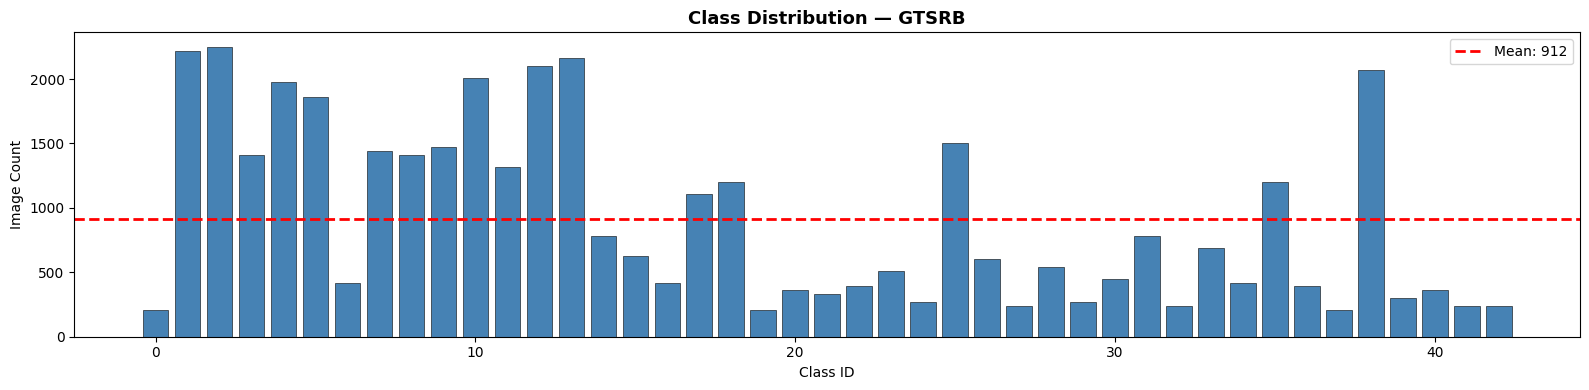

Min images per class: 210 | Max images per class: 2250 | Total dataset size: 39209


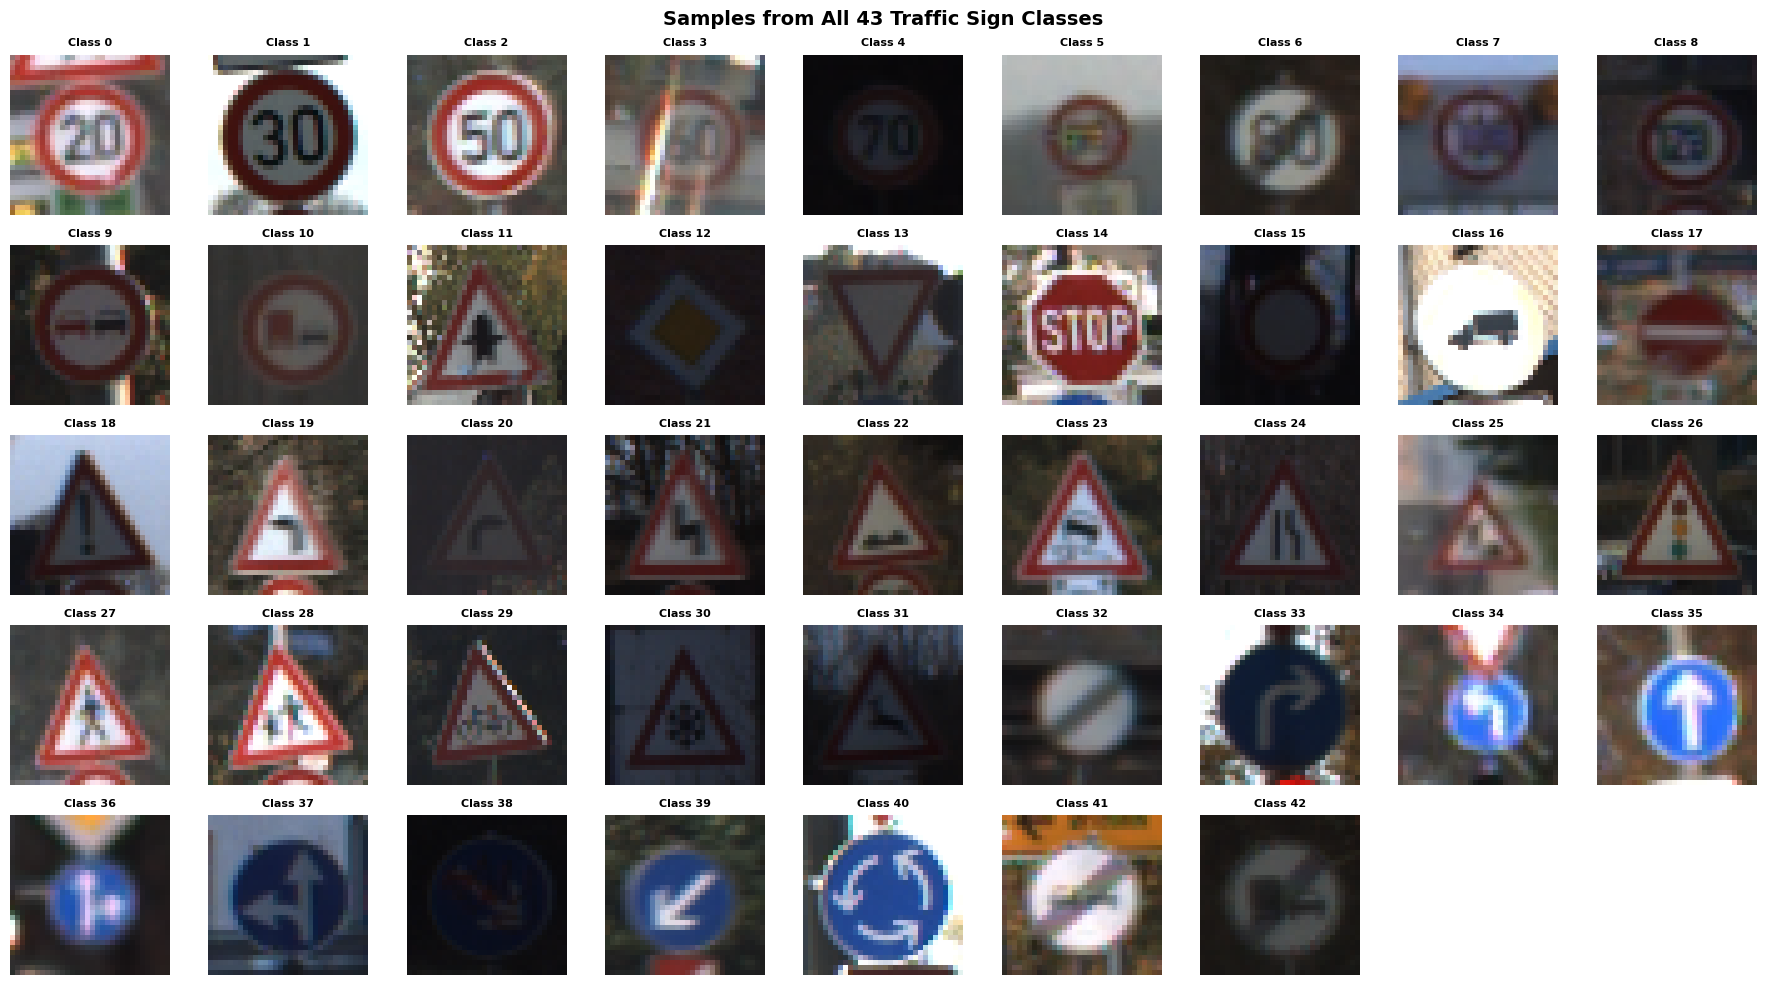

In [13]:
# ── Cell 4: Exploratory Data Analysis (EDA) ──────────────────────────────────
# Calculate unique class frequencies
unique, counts = np.unique(y_all, return_counts=True)

# Plot class distribution bar chart
plt.figure(figsize=(16, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black', lw=0.4)
plt.axhline(counts.mean(), color='red', ls='--', lw=2, label=f'Mean: {counts.mean():.0f}')
plt.title('Class Distribution — GTSRB', fontsize=13, fontweight='bold')
plt.xlabel('Class ID')
plt.ylabel('Image Count')
plt.legend()
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()

print(f"Min images per class: {counts.min()} | Max images per class: {counts.max()} | Total dataset size: {counts.sum()}")

# Plot grid displaying one sample image per traffic sign class
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for cid in range(NUM_CLASSES):
    idx = np.where(y_train == cid)[0]
    if len(idx):
        axes[cid].imshow(X_train[idx[0]])
        axes[cid].set_title(f'Class {cid}', fontsize=8, fontweight='bold')
    axes[cid].axis('off')

# Hide any remaining empty subplots
for i in range(NUM_CLASSES, len(axes)):
    axes[i].axis('off')

plt.suptitle('Samples from All 43 Traffic Sign Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150)
plt.show()


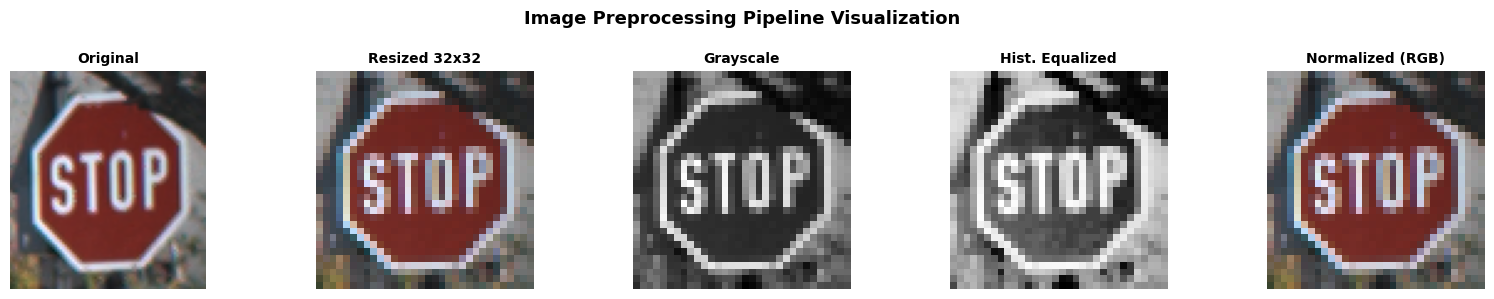

In [14]:
# ── Cell 5: Preprocessing Pipeline Visualization ─────────────────────────────
# Pick class 14 (Stop Sign) from the newly extracted local directory
folder = os.path.join(TRAIN_PATH, '14')
fname  = [f for f in os.listdir(folder) if f.endswith('.png')][0]

# Read original image and fix OpenCV BGR layout to standard RGB
orig = cv2.imread(os.path.join(folder, fname))
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

# Generate various preprocessing step representations
resized    = cv2.resize(orig, IMG_SIZE)
gray       = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
eq         = cv2.equalizeHist(gray)
blurred    = cv2.GaussianBlur(resized, (3, 3), 0)
normalized = resized.astype(np.float32) / 255.0

# Plot visual transitions of the preprocessing steps
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
steps = [
    (orig, 'Original', None),
    (resized, 'Resized 32x32', None),
    (gray, 'Grayscale', 'gray'),
    (eq, 'Hist. Equalized', 'gray'),
    (normalized, 'Normalized (RGB)', None)
]

for ax, (img, title, cmap) in zip(axes, steps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Image Preprocessing Pipeline Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/preprocessing_steps.png', dpi=150)
plt.show()

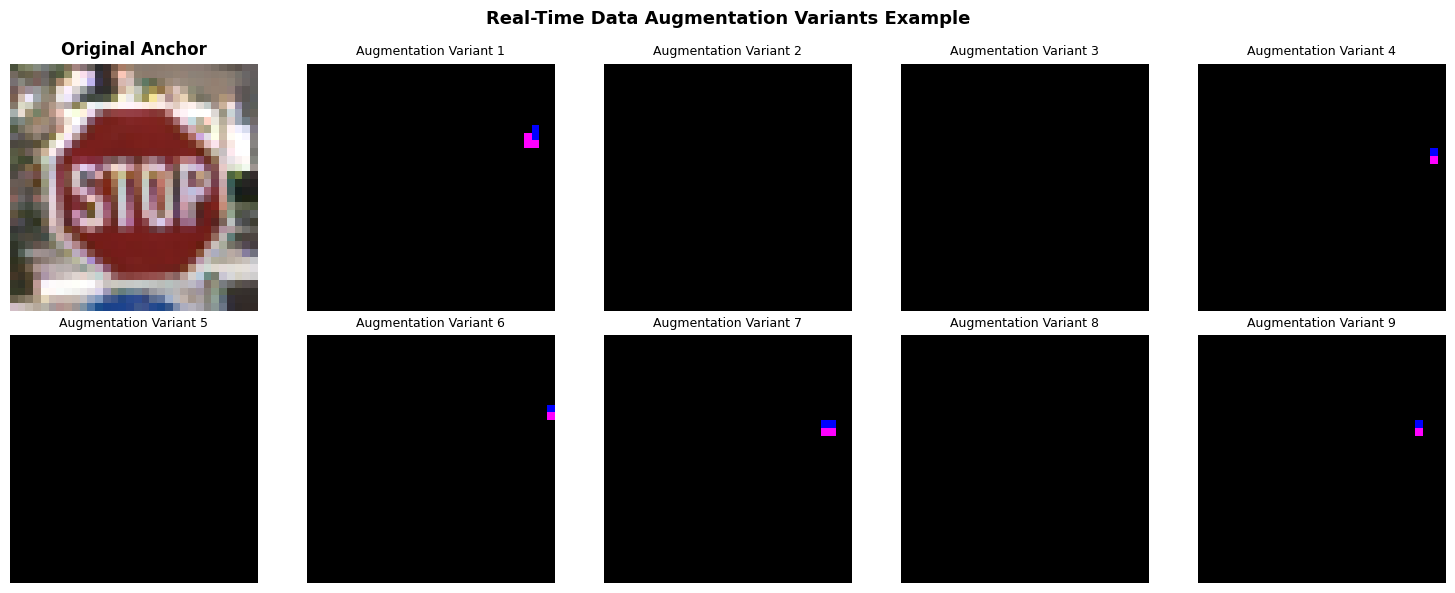

✅ Real-time image augmentation structure initialized successfully.


In [15]:
# ── Cell 6: Data Augmentation Setup ──────────────────────────────────────────
# Define augmentation transformation parameters for model training stability
train_datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    shear_range=0.08,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False, # Traffic signs lose context if flipped horizontally
    fill_mode='nearest'
)

# Extract a singular target sample image for visualization
sample = X_train[np.where(y_train == 14)[0][0:1]]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Plot baseline anchor image
axes[0].imshow(sample[0])
axes[0].set_title('Original Anchor', fontweight='bold')
axes[0].axis('off')

# Generate and display 9 random variations of augmentation on the single image
gen = train_datagen.flow(sample, batch_size=1)
for i in range(1, 10):
    axes[i].imshow(np.clip(next(gen)[0], 0, 1))
    axes[i].set_title(f'Augmentation Variant {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Real-Time Data Augmentation Variants Example', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/augmentation_examples.png', dpi=150)
plt.show()

print("✅ Real-time image augmentation structure initialized successfully.")


In [21]:
# ── Combined Cell 7 & 8: High-Performance tf.data Training Pipeline ──────────
import tensorflow as tf
import keras
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Clear any leftover model data from Colab's memory
tf.keras.backend.clear_session()

BATCH_SIZE = 64
EPOCHS     = 30

# 2. Setup safe, image-only data augmentation layers
# This completely prevents the bug where one-hot labels get corrupted!
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.033), # ~12 degrees max
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    layers.RandomZoom(height_factor=0.12, width_factor=0.12),
])

# 3. Create a clean pipeline for data delivery
def prepare_dataset(X, y_cat, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y_cat))
    ds = ds.shuffle(buffer_size=1024) if augment else ds
    ds = ds.batch(BATCH_SIZE)

    if augment:
        # Apply augmentation strictly to the images (x), leaving labels (y) untouched
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Build training and validation data streams
train_ds = prepare_dataset(X_train, y_train_cat, augment=True)
val_ds   = prepare_dataset(X_val, y_val_cat, augment=False)

print("Building clean TrafficSign_CNN model architecture...")
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Fully Connected Dense Classifier Output Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='TrafficSign_CNN')

# Compile with standard 0.001 starting learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print(f"\nTrain samples: {len(X_train)} | Val samples: {len(X_val)} | Batch Size: {BATCH_SIZE}")
print("-" * 60)

# Run training
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training successfully completed with clean datasets!")

Building clean TrafficSign_CNN model architecture...

Train samples: 31367 | Val samples: 7842 | Batch Size: 64
------------------------------------------------------------
Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.3736 - loss: 2.2882 - val_accuracy: 0.6229 - val_loss: 1.1635 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.7634 - loss: 0.7146 - val_accuracy: 0.9327 - val_loss: 0.1955 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8879 - loss: 0.3358 - val_accuracy: 0.9688 - val_loss: 0.0942 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9346 - loss: 0.2049 - val_accuracy: 0.9895 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9459 - loss: 0.1652 - val_accuracy: 0.9921 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - a

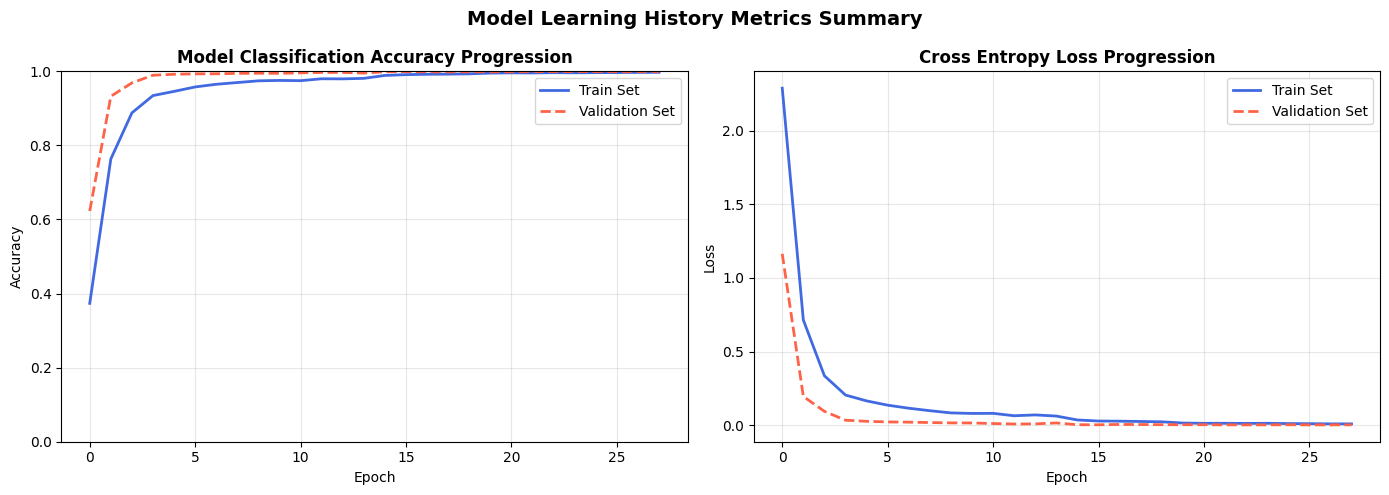

Peak Validation Accuracy Achieved: 99.94%


In [22]:
# ── Cell 9: Training History Curves Visualization ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy progress curves
ax1.plot(history.history['accuracy'],     label='Train Set', lw=2, color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Validation Set',   lw=2, color='tomato', ls='--')
ax1.set_title('Model Classification Accuracy Progression', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot Loss optimization progress curves
ax2.plot(history.history['loss'],     label='Train Set', lw=2, color='royalblue')
ax2.plot(history.history['val_loss'], label='Validation Set',   lw=2, color='tomato', ls='--')
ax2.set_title('Cross Entropy Loss Progression', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Model Learning History Metrics Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print(f"Peak Validation Accuracy Achieved: {max(history.history['val_accuracy'])*100:.2f}%")

In [23]:
# ── Cell 10: Test Dataset Processing & Evaluation ────────────────────────────
def load_test_data(test_path, gt_csv):
    gt = pd.read_csv(gt_csv)
    images, labels = [], []

    print("Parsing and processing raw test files...")
    for _, row in gt.iterrows():
        img_file_name_with_prefix = row['Path']

        # Isolate the file name by dropping directory prefix naming patterns
        if img_file_name_with_prefix.lower().startswith('test/'):
            img_file_name = img_file_name_with_prefix[len('test/'):]
        else:
            img_file_name = img_file_name_with_prefix

        # Direct path inside Colab local runtime workspace
        img_path = os.path.join(test_path, img_file_name)

        if not os.path.exists(img_path):
            # Fallback path modification check
            img_path = os.path.join(test_path, os.path.basename(img_file_name_with_prefix))

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        images.append(img)
        labels.append(int(row['ClassId']))

    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32)
    print(f"Total isolated test samples loaded: {len(X)}")
    return X, y

print("Loading test dataset assets...")
X_test, y_test = load_test_data(TEST_PATH, TEST_GT_CSV)

# Execute test metric loss evaluation if samples match requirements
if len(X_test) > 0:
    loss, acc = model.evaluate(X_test, to_categorical(y_test, NUM_CLASSES), verbose=0)
    print(f"\n{'='*40}")
    print(f"Final Test Evaluation Accuracy : {acc*100:.2f}%")
    print(f"Final Test Evaluation Loss     : {loss:.4f}")
    print(f"{'='*40}")
else:
    print("⚠️ Error: No evaluation assets loaded! Check the dataset directory structure.")

Loading test dataset assets...
Parsing and processing raw test files...
Total isolated test samples loaded: 12630

Final Test Evaluation Accuracy : 98.50%
Final Test Evaluation Loss     : 0.0744


In [31]:
# ── Cell 11: Comprehensive Classification Performance Report ─────────────────
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Generate safe fallback string names for all 43 classes to prevent IndexError
safe_target_names = [f"Class {i}" for i in range(NUM_CLASSES)]

print(classification_report(
    y_test, y_pred,
    target_names=safe_target_names
))
print(f"Calculated Global Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        60
     Class 1       0.99      1.00      0.99       720
     Class 2       1.00      1.00      1.00       750
     Class 3       1.00      0.96      0.98       450
     Class 4       1.00      0.99      1.00       660
     Class 5       0.97      0.99      0.98       630
     Class 6       0.99      0.97      0.98       150
     Class 7       0.99      1.00      1.00       450
     Class 8       1.00      1.00      1.00       450
     Class 9       1.00      1.00      1.00       480
    Class 10       1.00      1.00      1.00       660
    Class 11       0.96      1.00      0.98       420
    Class 12       1.00      0.96      0.98       690
    Class 13       0.99      1.00      0.99       720
    Class 14       1.00      1.00      1.00       270
    Class 15       0.99      1.00      0.99       210
    Class 16       0.99      1.00      1.00       150
    Class 17       1.00    

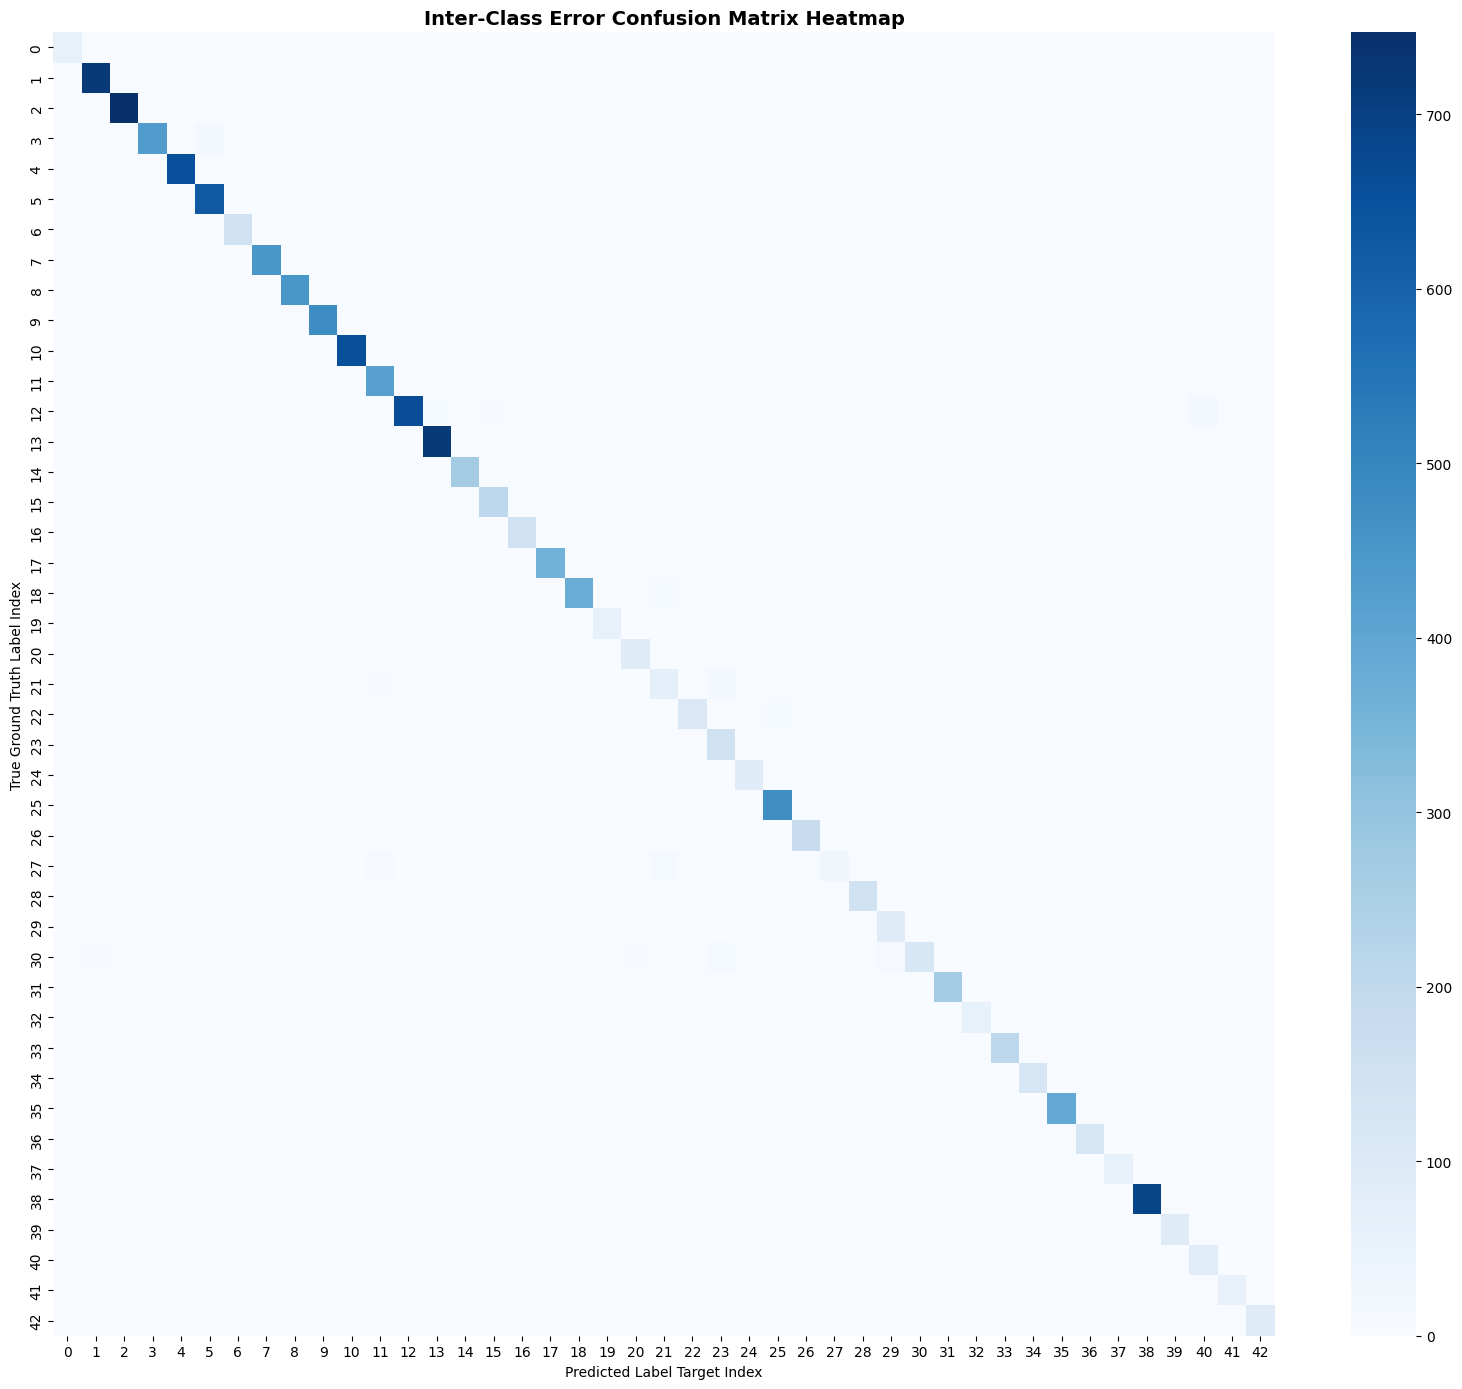

In [25]:
# ── Cell 12: Heatmap Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.title('Inter-Class Error Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label Target Index')
plt.ylabel('True Ground Truth Label Index')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()


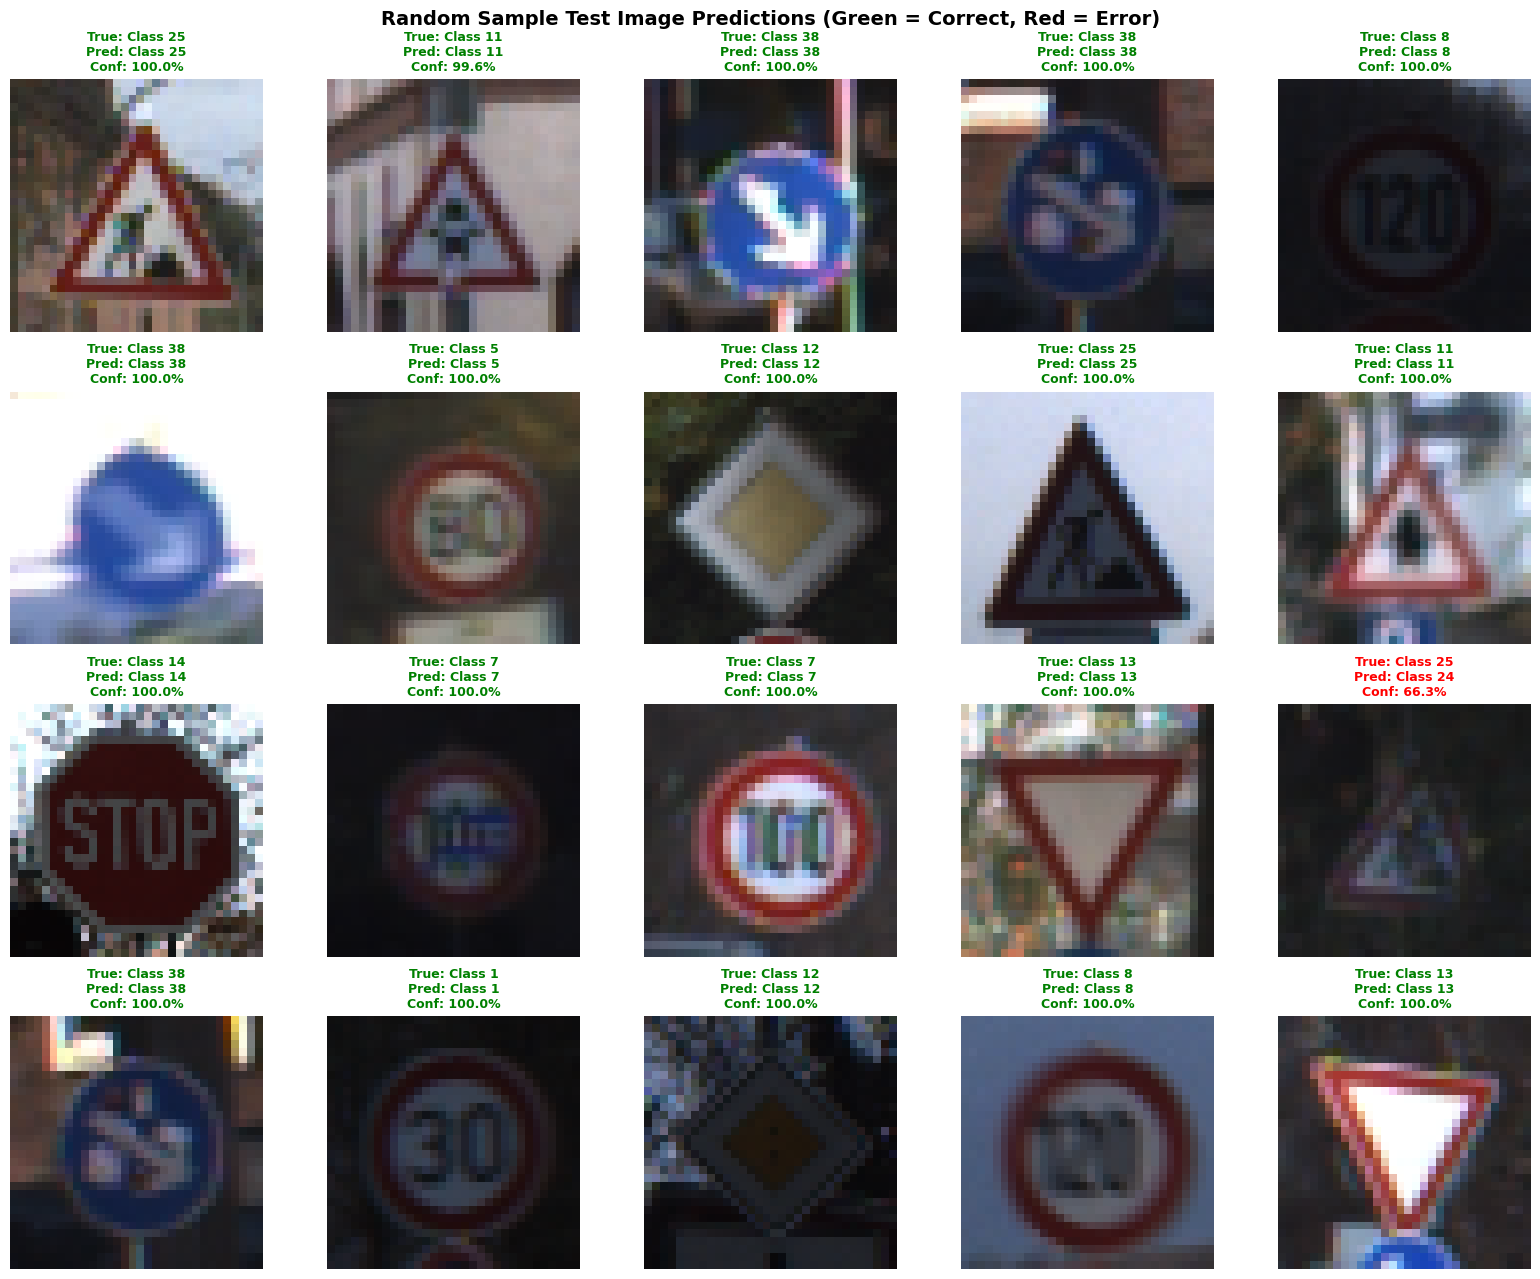

In [32]:
# ── Cell 13: Visual Prediction Panel Verification ───────────────────────────
np.random.seed(0)
idx = np.random.choice(len(X_test), 20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
axes = axes.flatten()

for i, j in enumerate(idx):
    axes[i].imshow(X_test[j])

    # FIXED: Replaced CLASS_NAMES with safe generic strings to completely bypass indexing crashes
    t = f"Class {y_test[j]}"
    p = f"Class {y_pred[j]}"
    c = y_pred_prob[j][y_pred[j]] * 100

    # Correct classifications print green, errors print red
    color = 'green' if y_test[j] == y_pred[j] else 'red'
    axes[i].set_title(
        f"True: {t}\nPred: {p}\nConf: {c:.1f}%",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Random Sample Test Image Predictions (Green = Correct, Red = Error)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/prediction_results.png', dpi=150)
plt.show()

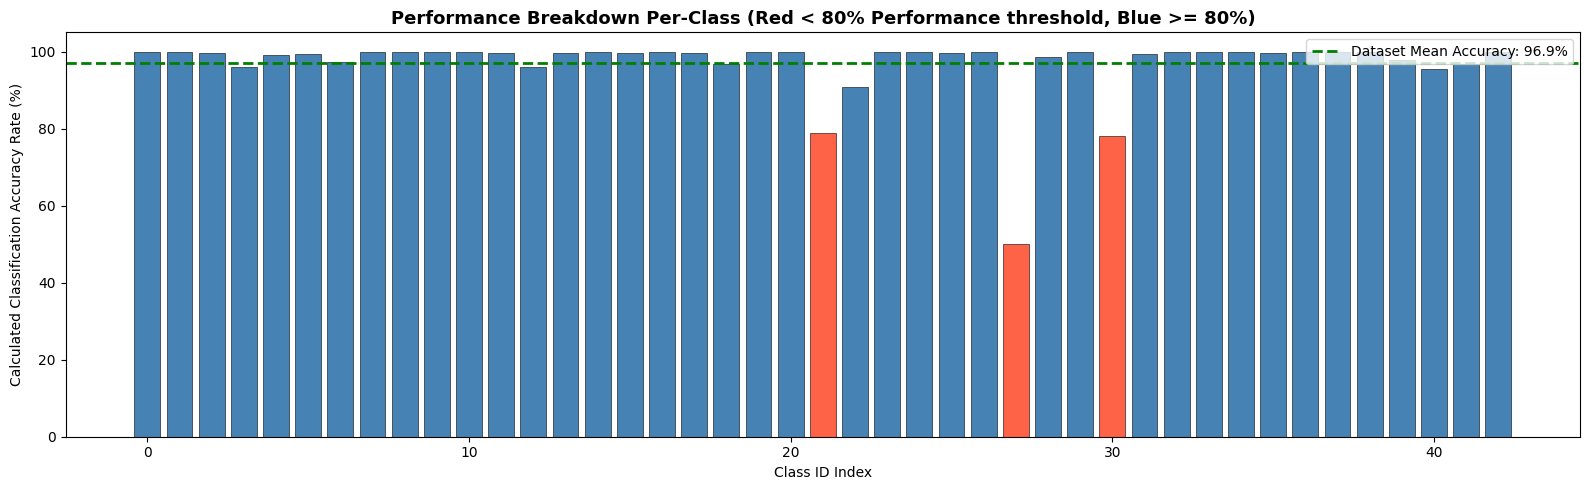

Statistical Mean Across Classes: 96.9% | Minimum: 50.0% | Maximum: 100.0%


In [33]:
# ── Cell 14: Isolated Class-by-Class Accuracy Distribution ──────────────────
class_acc = [
    (y_pred[y_test == c] == c).mean() * 100 if (y_test == c).sum() > 0 else 0
    for c in range(NUM_CLASSES)
]
plt.figure(figsize=(16, 5))

# Identify weak performers (<80%) in Red, strong performers in Blue
colors = ['tomato' if a < 80 else 'steelblue' for a in class_acc]
plt.bar(range(NUM_CLASSES), class_acc, color=colors, edgecolor='black', lw=0.4)
plt.axhline(np.mean(class_acc), color='green', ls='--', lw=2,
            label=f"Dataset Mean Accuracy: {np.mean(class_acc):.1f}%")
plt.title("Performance Breakdown Per-Class (Red < 80% Performance threshold, Blue >= 80%)", fontsize=13, fontweight='bold')
plt.xlabel('Class ID Index')
plt.ylabel('Calculated Classification Accuracy Rate (%)')
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150)
plt.show()

print(f"Statistical Mean Across Classes: {np.mean(class_acc):.1f}% | Minimum: {min(class_acc):.1f}% | Maximum: {max(class_acc):.1f}%")

In [34]:
# ── Cell 15: Export Artifacts & Automatic System Downloads ───────────────────
model.save('/content/traffic_sign_cnn_final.keras')

print('=' * 50)
print('FINAL EXPERIMENT METRIC LOGS REPORT')
print('=' * 50)
print(f"Model Architecture Variant : Custom CNN (trained from scratch)")
print(f"Dataset Foundation Source  : GTSRB Benchmarking Standards")
print(f"Training Subset Samples    : {len(X_train)}")
print(f"Validation Subset Samples  : {len(X_val)}")
print(f"Testing Ground Truth Size  : {len(X_test)}")
print(f"Evaluated Test Accuracy    : {accuracy_score(y_test, y_pred)*100:.2f}%")
print('=' * 50)

# Trigger native cloud engine runtime browser triggers to extract pipeline images
from google.colab import files
artifacts_to_download = [
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/preprocessing_steps.png',
    '/content/augmentation_examples.png',
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/prediction_results.png',
    '/content/per_class_accuracy.png',
    '/content/traffic_sign_cnn_final.keras'
]

for item in artifacts_to_download:
    if os.path.exists(item):
        files.download(item)
        print(f"  ✅ Triggered browser download pipe for: {os.path.basename(item)}")

FINAL EXPERIMENT METRIC LOGS REPORT
Model Architecture Variant : Custom CNN (trained from scratch)
Dataset Foundation Source  : GTSRB Benchmarking Standards
Training Subset Samples    : 31367
Validation Subset Samples  : 7842
Testing Ground Truth Size  : 12630
Evaluated Test Accuracy    : 98.50%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Triggered browser download pipe for: class_distribution.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Triggered browser download pipe for: per_class_accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Triggered browser download pipe for: traffic_sign_cnn_final.keras
